# Plot epoch metrics
Select the run directory by editing `run_dir`, then run the next cell to visualize all stored metrics on a single plot.

In [10]:
def plot_epoch_metrics(run_dir):
    
    """Plot all epoch metrics from a training run directory.
    
    Args:
        run_dir: Path to the run directory containing epoch_metrics.csv
    """
    from pathlib import Path
    import ast
    import pandas as pd
    import matplotlib.pyplot as plt
    
    run_dir = Path(run_dir)
    metrics_path = run_dir / "epoch_metrics.csv"
    
    # Load metrics
    raw = pd.read_csv(metrics_path)
    
    # Parse metric values so lists like "[1.0]" become scalars
    def _to_scalar(val):
        try:
            return float(val)
        except (TypeError, ValueError):
            pass
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, (list, tuple)) and len(parsed) == 1:
                return float(parsed[0])
            if isinstance(parsed, (int, float)):
                return float(parsed)
        except Exception:
            return None
        return None
    
    raw["metric_value_parsed"] = raw["metric_value"].apply(_to_scalar)
    
    # Create a column per (phase, metric_name)
    raw["series"] = raw["phase"] + ":" + raw["metric_name"]
    wide = raw.pivot_table(
        index="epoch_idx",
        columns="series",
        values="metric_value_parsed",
        aggfunc="mean",
    ).sort_index()
    
    # Plot each series on its own y-scale but shared x-axis
    fig, base_ax = plt.subplots(figsize=(10, 6))
    axes = [base_ax]
    colors = plt.cm.tab10(range(len(wide.columns)))
    
    for i, col in enumerate(wide.columns):
        ax = axes[0] if i == 0 else base_ax.twinx()
        if i > 0:
            # Offset additional y-axes to keep them visible
            ax.spines["right"].set_position(("axes", 1 + 0.12 * (i - 1)))
            axes.append(ax)
        ax.plot(wide.index, wide[col], color=colors[i], label=col)
        ax.set_ylabel(col, color=colors[i])
        ax.tick_params(axis="y", colors=colors[i])
        
        # Mark highest point for accuracy metrics
        if "acc" in col.lower():
            max_idx = wide[col].idxmax()
            max_val = wide[col].max()
            ax.plot(max_idx, max_val, 'r*', markersize=15, zorder=5)
            ax.annotate(f'Max: {max_val:.4f}\nEpoch: {max_idx}',
                       xy=(max_idx, max_val),
                       xytext=(-40, -40),
                       textcoords='offset points',
                       bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
                       arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
    
    # Combine legends from all axes
    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    base_ax.legend(
        handles,
        labels,
        title="Metric",
        loc="center right"
    )
    
    base_ax.set_xlabel("Epoch")
    base_ax.set_title(f"Epoch metrics for {run_dir.name}")
    base_ax.grid(True)
    plt.tight_layout()
    plt.show()

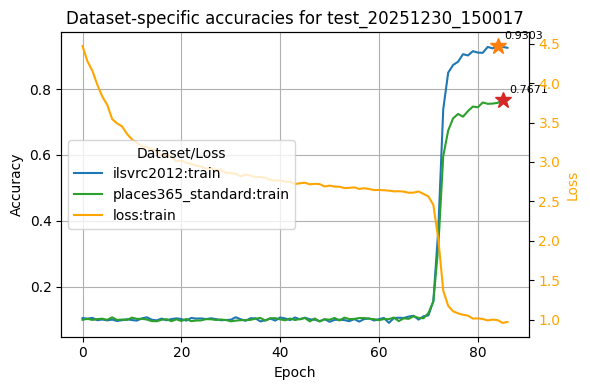

In [28]:
def plot_dataset_accuracies_new(run_dir):
    """Plot dataset-specific accuracy curves on the same graph and overlay loss."""
    from pathlib import Path
    import ast
    import pandas as pd
    import matplotlib.pyplot as plt

    run_dir = Path(run_dir)
    metrics_path = run_dir / "epoch_metrics.csv"

    def _to_scalar(val):
        try:
            return float(val)
        except (TypeError, ValueError):
            pass
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, (list, tuple)) and len(parsed) == 1:
                return float(parsed[0])
            if isinstance(parsed, (int, float)):
                return float(parsed)
        except Exception:
            return None
        return None

    raw = pd.read_csv(metrics_path)
    raw["metric_value_parsed"] = raw["metric_value"].apply(_to_scalar)

    dataset_df = raw[raw["metric_name"].str.startswith("acc_")].copy()
    if dataset_df.empty:
        raise ValueError(f"No dataset accuracy metrics in {metrics_path}")

    dataset_df["dataset"] = dataset_df["metric_name"].str.removeprefix("acc_")

    fig, ax = plt.subplots(figsize=(6, 4))
    
    for dataset, subset in dataset_df.groupby("dataset"):
        pivot = (
            subset.groupby(["phase", "epoch_idx"])["metric_value_parsed"]
            .mean()
            .unstack(level=0)
            .sort_index()
        )
        for phase in pivot.columns:
            label = f"{dataset}:{phase}"
            ax.plot(
                pivot.index,
                pivot[phase],
                label=label,
            )
            peak_idx = pivot[phase].idxmax()
            peak_val = pivot[phase].max()
            ax.plot(peak_idx, peak_val, '*', markersize=12, zorder=5)
            ax.annotate(
                f"{peak_val:.4f}",
                xy=(peak_idx, peak_val),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8
            )
    
    loss_df = raw[raw["metric_name"] == "loss"].copy()
    if not loss_df.empty:
        ax_loss = ax.twinx()
        loss_pivot = (
            loss_df.groupby(["phase", "epoch_idx"])["metric_value_parsed"]
            .mean()
            .unstack(level=0)
            .sort_index()
        )
        for phase in loss_pivot.columns:
            label = f"loss:{phase}"
            ax_loss.plot(
                loss_pivot.index,
                loss_pivot[phase],
                linestyle="-",
                label=label,
                color="orange",
            )
        ax_loss.set_ylabel("Loss", color="orange")
        ax_loss.tick_params(axis="y", labelcolor="orange")
        ax_loss.spines["right"].set_visible(True)

        handles1, labels1 = ax.get_legend_handles_labels()
        handles2, labels2 = ax_loss.get_legend_handles_labels()
        ax_loss.legend(handles1 + handles2, labels1 + labels2, title="Dataset/Loss", loc="center left")
    else:
        ax.legend(title="Dataset:Phase", loc="center left")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"Dataset-specific accuracies for {run_dir.name}")
    ax.grid(True)
    plt.tight_layout()
    plt.show()

plot_dataset_accuracies_new("output/duckdb_test/test_20251230_150017")


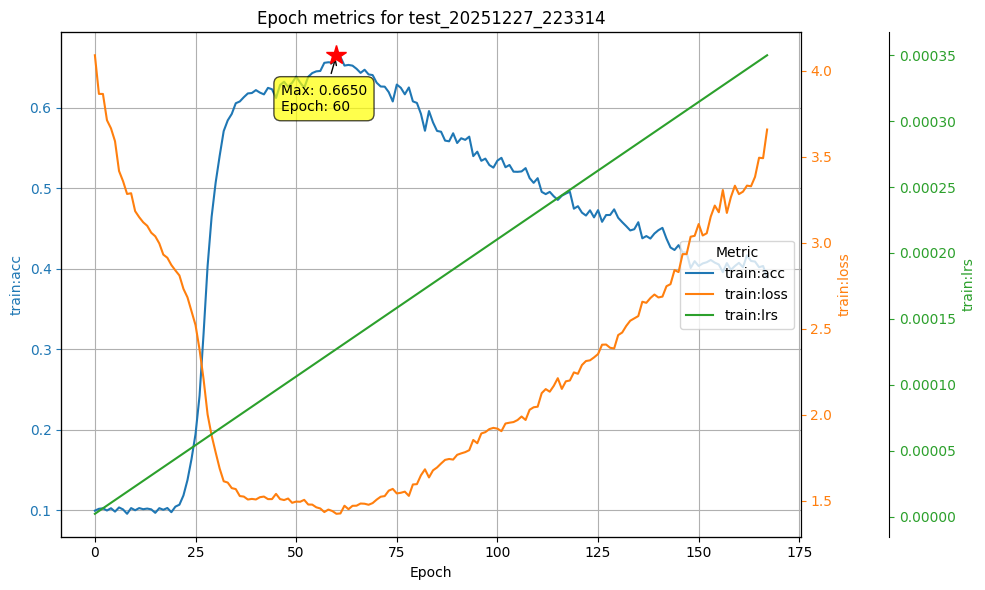

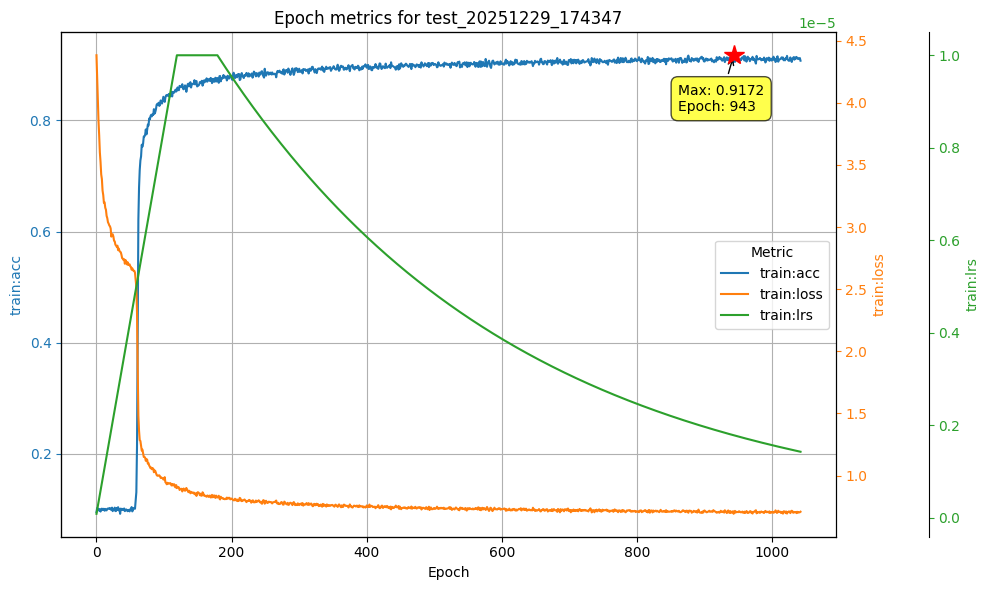

In [12]:
plot_epoch_metrics("output/duckdb_test/test_20251227_223314")

plot_epoch_metrics("output/duckdb_test/test_20251229_174347")